## Peak performance comparison of AIV column_sweep matrix inverse

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [ ]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [16]

In [65]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [66]:
PREFIX_PATH = "../../"

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_tri_inv_col_sweep_{tile}_{dtype}.csv")
    df_tmp["S"] = f"AIV col-sweep s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_tri_inv_cube_col_sweep_{tile}_{dtype}.csv")
    df_tmp["S"] = f"MIX col-sweep s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])
    #df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_tri_inv_baseline_{tile}_{dtype}.csv")
    #df_tmp["S"] = f"(PT) s={tile}"
    #df_tiled = pd.concat([df_tiled, df_tmp])


add_stats_siso(df_tiled, 2)

df = pd.concat([df_tiled])

In [67]:
df.head()

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,tri_inv_col_sweep_64_fp16,fp16,4,None,4,299.04,AIV col-sweep s=64,2,16,0.000013,0.000054
1,tri_inv_col_sweep_64_fp16,fp16,6,None,6,296.87,AIV col-sweep s=64,2,24,0.000020,0.000081
2,tri_inv_col_sweep_64_fp16,fp16,8,None,8,296.38,AIV col-sweep s=64,2,32,0.000027,0.000108
3,tri_inv_col_sweep_64_fp16,fp16,10,None,10,297.62,AIV col-sweep s=64,2,40,0.000034,0.000134
4,tri_inv_col_sweep_64_fp16,fp16,12,None,12,297.08,AIV col-sweep s=64,2,48,0.000040,0.000162


## Paper plots

/tmp/ipykernel_1158671/2935107068.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1158671/2935107068.py:8: UserWarning: The markers list has more values (7) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


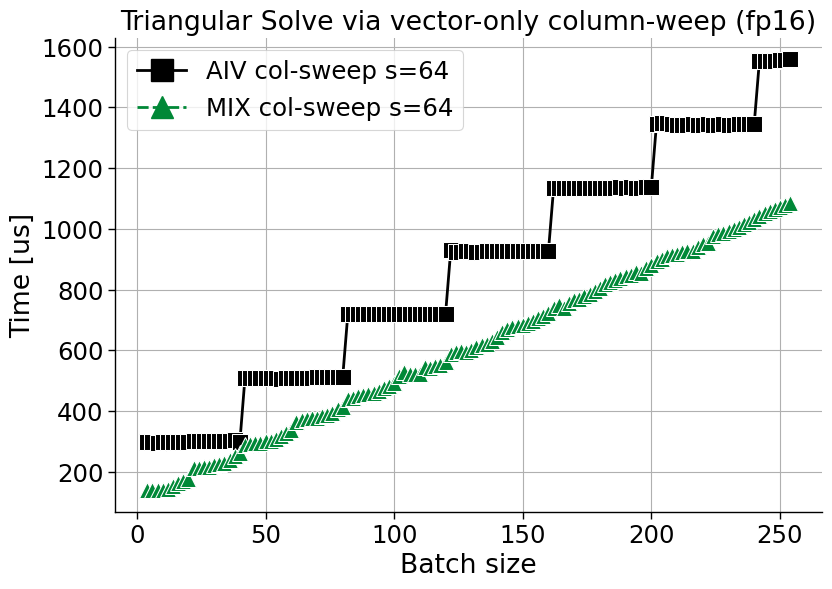

<Figure size 870x627 with 0 Axes>

In [68]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Triangular Solve via vector-only column-weep ({dtype})")
ax.set_xlabel("Batch size")
ax.set_ylabel("Time [us]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/tri_inv_col_sweep_{dtype}.png")
plt.show()
plt.clf()
